In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import os

In [3]:
# 1. CẤU HÌNH
# Danh sách tên các model và tên file tương ứng
models_config = {
    'Linear Regression': 'LN.csv',
    'Random Forest': 'RF.csv',
    'XGBoost': 'XG.csv',
    'LightGBM': 'LGBM.csv',
    #'LSTM (only Gold)': 'LSTM.csv' 
}
# Đường dẫn đến folder chứa file CSV kết quả
PRED_DIR = '../../results/predictions/'

In [4]:
# 2. HÀM ĐÁNH GIÁ HIỆU SUẤT
metrics_list = []
dfs = {} # Lưu data của từng model để vẽ

print("📊 Đang tổng hợp kết quả...")

for model_name, file_name in models_config.items():
    file_path = os.path.join(PRED_DIR, file_name)
    
    if os.path.exists(file_path):
        # Đọc dữ liệu
        df = pd.read_csv(file_path, parse_dates=['Datetime'])
        dfs[model_name] = df
        
        # Tính toán chỉ số
        y_true = df['Actual']
        y_pred = df['Predicted']
        
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        # Lưu vào list để tạo bảng so sánh
        metrics_list.append({
            'Model': model_name,
            'MAE': mae,
            'RMSE': rmse,
            'R2 Score': r2
        })
    else:
        print(f"⚠️ Không tìm thấy file: {file_name}")

📊 Đang tổng hợp kết quả...


In [5]:
# Tạo bảng tổng sắp (DataFrame)
metrics_df = pd.DataFrame(metrics_list)
# Sắp xếp theo MAE từ thấp đến cao (Càng thấp càng tốt)
metrics_df = metrics_df.sort_values(by='MAE', ascending=True)

print("\n🏆 BẢNG XẾP HẠNG HIỆU SUẤT:")
print(metrics_df)

# Lưu bảng này lại để dán vào báo cáo
metrics_df.to_csv('../../results/final_comparison_metrics.csv', index=False)


🏆 BẢNG XẾP HẠNG HIỆU SUẤT:
               Model       MAE      RMSE   R2 Score
0  Linear Regression  0.000401  0.002986   0.985669
3           LightGBM  0.003780  0.022464   0.189083
2            XGBoost  0.007815  0.024103   0.066480
1      Random Forest  0.067182  0.146332 -33.408408


C:\Users\minam\AppData\Local\Temp\ipykernel_6024\1210338327.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='MAE', y='Model', palette='viridis')


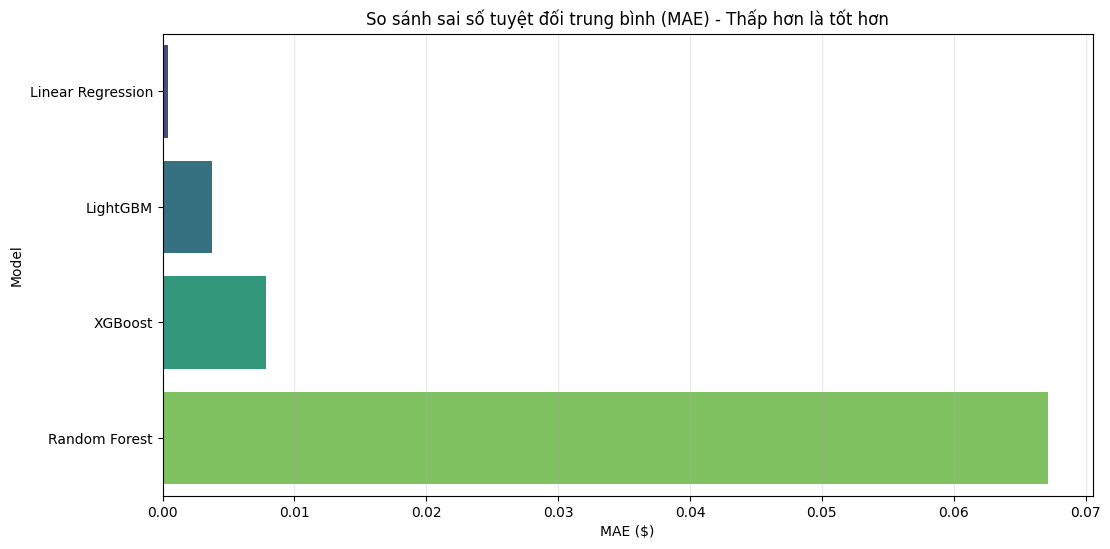

In [6]:
# ==============================================================================
# 3. TRỰC QUAN HÓA (VẼ BIỂU ĐỒ)
# ==============================================================================

# A. Biểu đồ so sánh MAE (Cột)
plt.figure(figsize=(12, 6))
sns.barplot(data=metrics_df, x='MAE', y='Model', palette='viridis')
plt.title('So sánh sai số tuyệt đối trung bình (MAE) - Thấp hơn là tốt hơn')
plt.xlabel('MAE ($)')
plt.grid(axis='x', alpha=0.3)
plt.show()

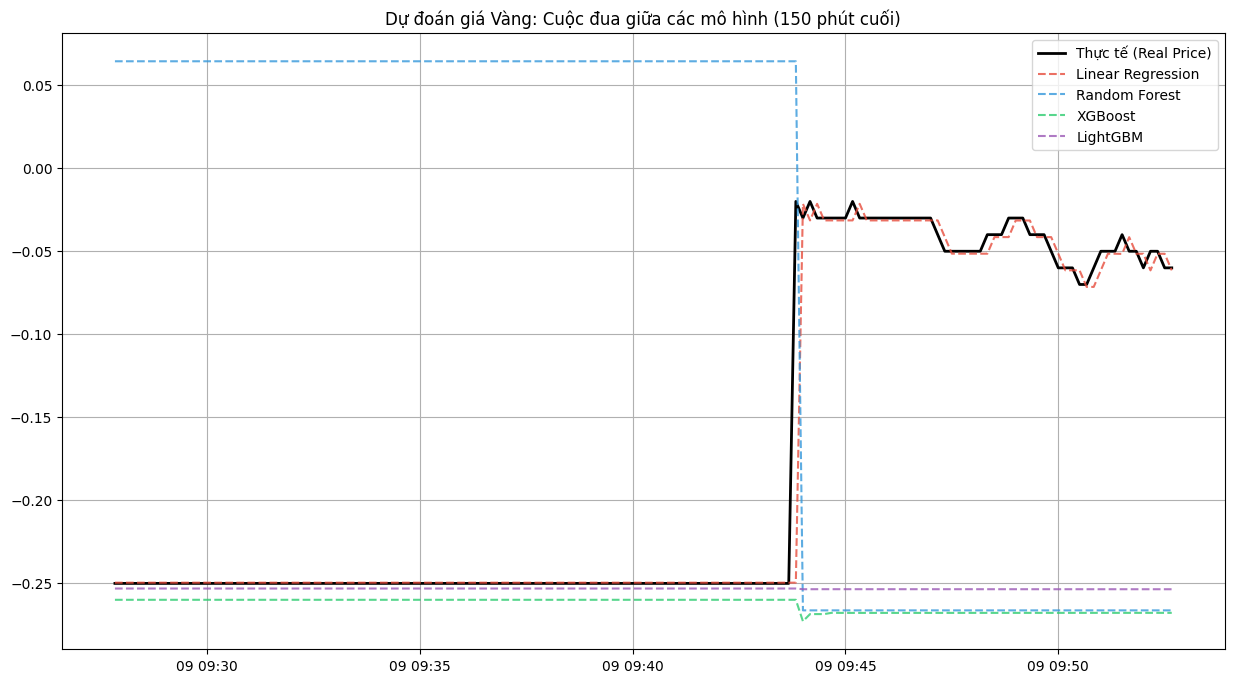

In [7]:
# B. Biểu đồ đường dự đoán (Line Chart)
# Vì vẽ cả 5 đường sẽ rất rối, ta chỉ vẽ đoạn 100-200 điểm cuối cùng
plt.figure(figsize=(15, 8))

# Lấy index thời gian từ model đầu tiên (giả sử các model test cùng khoảng thời gian)
first_model = list(dfs.keys())[0]
sample_df = dfs[first_model].tail(150) # Lấy 150 điểm cuối
time_index = sample_df['Datetime']

# Vẽ đường thực tế (Actual) - Chỉ cần vẽ 1 lần
plt.plot(time_index, sample_df['Actual'], label='Thực tế (Real Price)', color='black', linewidth=2, linestyle='-')

# Vẽ đường dự đoán của các model
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6', '#f1c40f'] # Màu sắc khác nhau
for i, (name, df_full) in enumerate(dfs.items()):
    subset = df_full.tail(150)
    plt.plot(subset['Datetime'], subset['Predicted'], label=name, color=colors[i], linestyle='--', alpha=0.8)

plt.title('Dự đoán giá Vàng: Cuộc đua giữa các mô hình (150 phút cuối)')
plt.legend()
plt.grid(True)
plt.show()

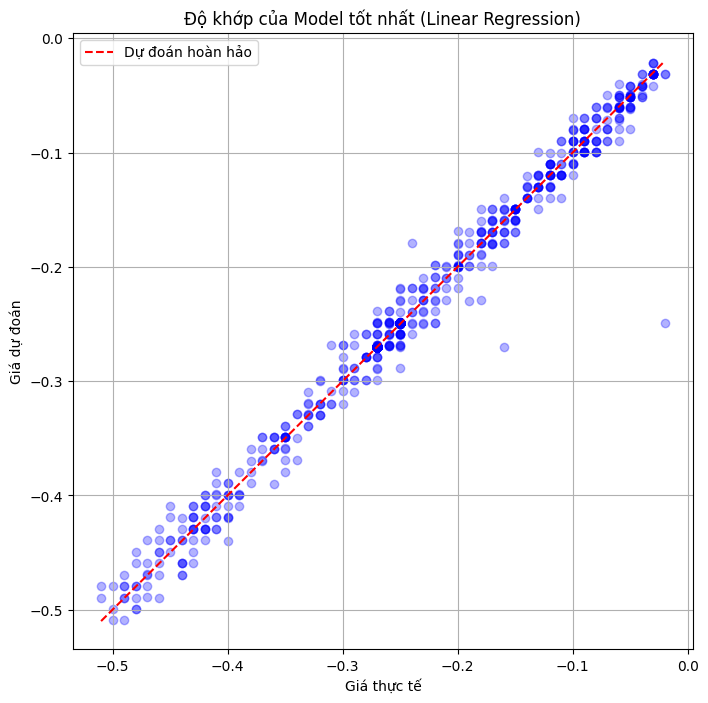

In [8]:
# C. Biểu đồ Scatter (Dự đoán vs Thực tế) - Chỉ vẽ model TỐT NHẤT
best_model_name = metrics_df.iloc[0]['Model'] # Lấy tên model đứng đầu bảng
best_df = dfs[best_model_name]

plt.figure(figsize=(8, 8))
plt.scatter(best_df['Actual'], best_df['Predicted'], alpha=0.3, color='blue')
# Vẽ đường chéo chuẩn (Hoàn hảo)
min_val = min(best_df['Actual'].min(), best_df['Predicted'].min())
max_val = max(best_df['Actual'].max(), best_df['Predicted'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Dự đoán hoàn hảo')

plt.title(f'Độ khớp của Model tốt nhất ({best_model_name})')
plt.xlabel('Giá thực tế')
plt.ylabel('Giá dự đoán')
plt.legend()
plt.grid(True)
plt.show()